In [2]:
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


/home/federico/Documentos/TUIA/.venv/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# EJERCICIO CLASE PRACTICA

In [3]:
# Importamos los datos, salteando todo lo que figura en las primeras 4 filas (completar ruta)
data_internet = pd.read_csv('datasets//data_internet.csv', skiprows = 4)

# Filtramos sólo algunos países
lista_paises = ['Iceland', 'Norway', 'United Kingdom', 'Japan', 'Canada', 'Germany', 'New Zealand',
                  'France', 'Israel', 'Argentina', 'United States', 'Chile', 'Italy', 'Brazil', 'Mexico',
                  'South Africa', 'China', 'Algeria', 'India', 'Kenia']

data_internet_filtrado = data_internet[(data_internet['Country Name'].isin(lista_paises))]

# Eliminamos columnas innecesarias
data_internet_filtrado = data_internet_filtrado.drop(['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68'], axis = 1)

# Nos quedamos únicamente con las columnas que tienen datos para todos los países que seleccionamos
data_internet_filtrado = data_internet_filtrado.dropna(axis = 1)

# Seteamos Country Name como index
data_internet_filtrado.set_index('Country Name', inplace = True)

In [4]:
df = data_internet_filtrado.loc[['Argentina', 'India', 'United States']]
df.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Country Name,,,,,,,,,,,,,,,,,,,,,
Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,3.284482,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,0.273224,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,35.848724,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [5]:
df = df.reset_index()
df.head()

,Country Name,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
1,India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
2,United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [6]:
# Convertimos a formato largo
df_largo = pd.melt(df, id_vars= "Country Name", var_name= 'Anio', value_name = 'Porcentaje')
df_largo

,Country Name,Anio,Porcentaje
0,Argentina,1990,0.000000
1,India,1990,0.000000
2,United States,1990,0.784729
3,Argentina,1991,0.000000
4,India,1991,0.000000
...,...,...,...
91,India,2020,43.405443
92,United States,2020,90.620470
93,Argentina,2021,87.150707
94,India,2021,46.310000


In [7]:
# Convertimos los años a tipo int
df_largo['Anio'] = df_largo['Anio'].astype(int)
df_largo.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  96 non-null     str    
 1   Anio          96 non-null     int64  
 2   Porcentaje    96 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.3 KB


<Axes: xlabel='Anio', ylabel='Porcentaje'>

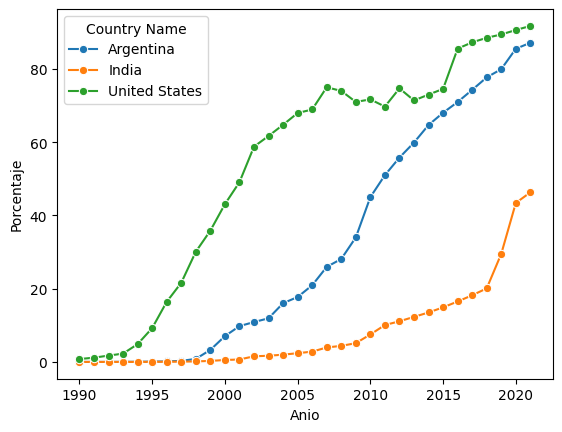

In [8]:
sns.lineplot(x= 'Anio', y= 'Porcentaje', hue='Country Name', marker= 'o', data=df_largo)

# EJERCICIO 1

In [9]:
iris = pd.read_csv("datasets/iris.csv")
iris.head(15)

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [10]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               150 non-null    int64  
 1   sepal_length_cm  150 non-null    float64
 2   sepal_width_cm   150 non-null    float64
 3   petal_length_cm  150 non-null    float64
 4   petal_width_cm   150 non-null    float64
 5   species          150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


PUNTO 1

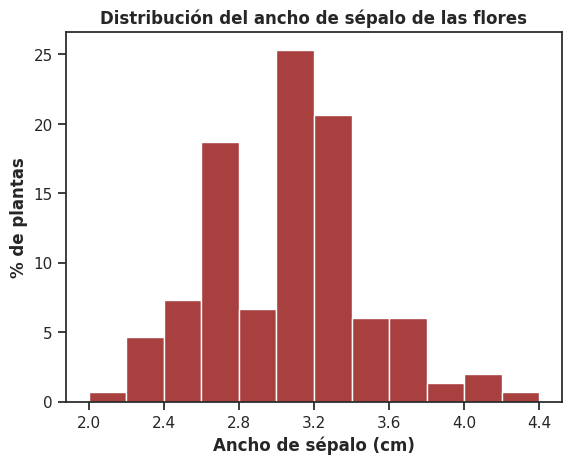

In [11]:
# Configuramos el estilo visual con marcas en los ejes
sns.set_theme(style='ticks')

# Dibujamos el histograma. El parametro stat=percent transforma el eje vertical para que muestre 
# porcentajes en lugar de frecuencias
# Ademas seteamos el ancho de los intervalos (binwidth) y el rango del grafico (binrange)
sns.histplot(data=iris, x='sepal_width_cm', color='darkred', stat='percent', binwidth=0.2, binrange=(2.0, 4.4))

# Definimos que las marcas del eje X vayan de 2.0 a 4.4, saltando de 0.4
plt.xticks(np.arange(2.0, 4.5, 0.4))

# Personalizamos los títulos según la consigna
plt.title('Distribución del ancho de sépalo de las flores', fontweight='bold')
plt.xlabel('Ancho de sépalo (cm)', fontweight='bold')
plt.ylabel('% de plantas', fontweight='bold')
plt.show()

PUNTO 2

<Axes: xlabel='species', ylabel='petal_length_cm'>

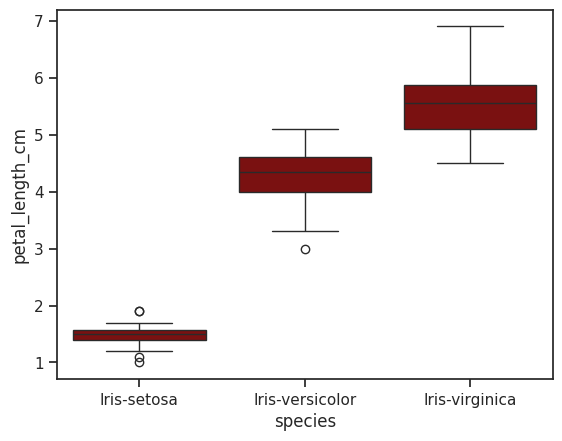

In [12]:
# Construimos el boxplot
sns.boxplot(y='petal_length_cm', x='species', data=iris, color='darkred')

Notamos que iris-setosa tiene un largo del considerablemente menor que las demas y su largo varia muy poco.
Ademas, iris-virginica es la que presenta una mayor mediana en el largo de su petalo.

PUNTO 3

In [13]:
# Primero vamos a calcular la media del largo de los petalos por especie
medias = iris.groupby('species')['petal_length_cm'].mean().round(2).reset_index()
medias

,species,petal_length_cm
0,Iris-setosa,1.46
1,Iris-versicolor,4.26
2,Iris-virginica,5.55


<Axes: xlabel='species', ylabel='petal_length_cm'>

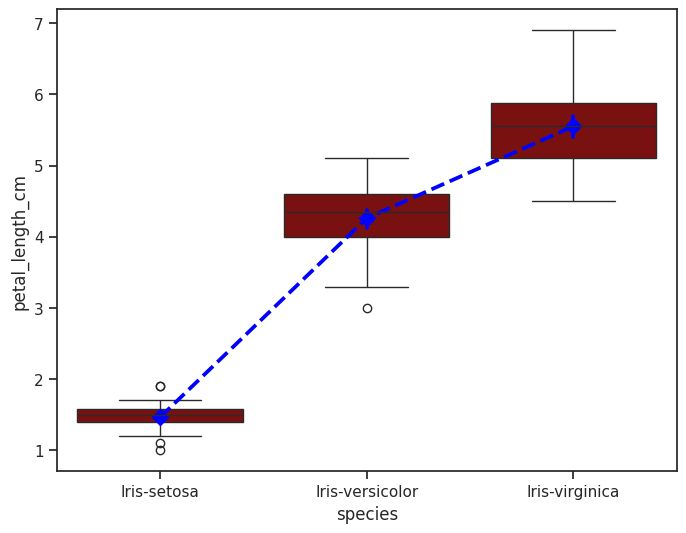

In [14]:
# Construimos nuevamente el boxplot
plt.figure(figsize=(8,6))
sns.boxplot(y='petal_length_cm', x='species', data=iris, color='darkred')

# Superponemos la media usando stripplot
# Usamos un marcador de diamante ('D') de color blanco para que resalte
#sns.stripplot(data=medias, x='species', y='petal_length_cm', 
#              color='white', marker='D', size=10, edgecolor='black', linewidth=1)

# Dibujamos el pointplot del largo del pétalo por especie
sns.pointplot(data=iris, x='species', y='petal_length_cm', 
              color='blue', markers='D', linestyles='--')

Como podemos ver, la media y la mediana tienen valores muy similares (casi identicos). Esto nos quiere decir que la distribucion de los datos es simetrica.

PUNTO 4

<Axes: title={'center': 'Distribución: Ancho de Pétalo'}, xlabel='petal_width_cm'>

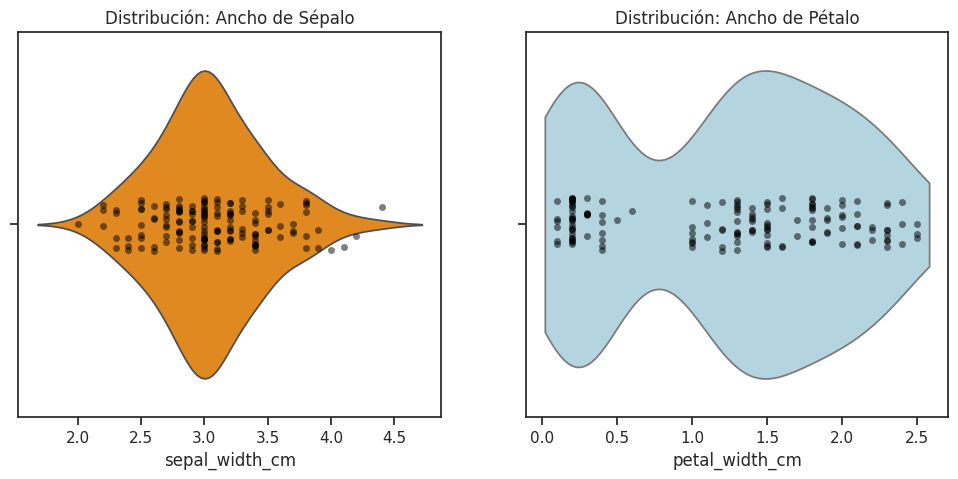

In [15]:
# Primero armamos el plano. Creamos la cuadricula, 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Construimos el primer grafico. Con ax=axes[0] le decimos a pandas donde ubicar el grafico (en este caso en la casilla 1)
sns.violinplot(data=iris, x='sepal_width_cm', color='darkorange', ax=axes[0], inner=None)
axes[0].set_title('Distribución: Ancho de Sépalo')

# Ahora construimos el segundo grafico similar al anterior. 
# El parametro inner sirve para que el violinplot no ponga su cajita caracteristica en el grafico, ya que vamos a superponerlo con un 
# stripplot y va a quedar sobrecargado
sns.violinplot(data=iris, x='petal_width_cm', color='lightblue', ax=axes[1], inner=None, cut=0.3)
axes[1].set_title('Distribución: Ancho de Pétalo')

# Agregamos informacion con stripplots.
# Para el ancho del sepalo
sns.stripplot(data=iris, x='sepal_width_cm', color='black', ax=axes[0], alpha=0.5, jitter=0.07)

# Para el ancho del petalo. Con el parametro alpha lo que hacemos para darle transparencia a los puntos. Donde
# se ve un color negro mas oscuro es porque hay mas densidad de puntos 
sns.stripplot(data=iris, x='petal_width_cm', color='black', ax=axes[1], alpha=0.5, jitter=0.07)


En la distribucion del ancho del sepalo notamos que se trata de:

    Distribucion Unimodal
    Distribucion Normal

En la distribucion del ancho del petalo notamos que se trata de:

    Distribucion Bimodal
    Distribucion sesgada a la derecha

PUNTO 5

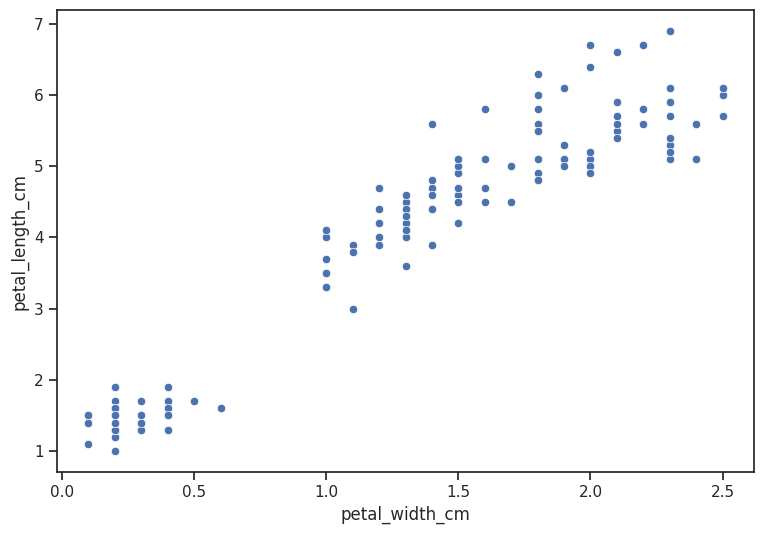

In [16]:
# Para cruzar ambas variables, utilizamos un grafico tipo scatterplot
plt.figure(figsize=(9,6))
sns.scatterplot(data=iris, x='petal_width_cm', y='petal_length_cm')

# Para determinar la medida de la fuerza de la correlacion, usamos el metodo .corr(pearson)
corr_petalo = iris['petal_length_cm'].corr(iris['petal_width_cm'])

Se nota claramente en el grafico una relacion lineal directa y fuerte entre las variables largo y ancho del petalo.

Lo terminamos de confirmar viendo el coeficiente de relacion entre estas variables, con un valor = 0.96 (medido con Pearson). 

# EJERCICIO 2

PUNTO 1

In [17]:
temperaturas = pd.read_fwf("datasets/registro_temperatura365d_smn.txt", encoding='latin1')
temperaturas.head(15)

,FECHA,TMAX,TMIN,NOMBRE
0,--------,-----,-----,----------------------------------------
1,10042026,21.1,13.8,AEROPARQUE AERO
2,10042026,22.6,7.2,AZUL AERO
3,10042026,24.8,11.4,BAHIA BLANCA AERO
4,10042026,24.6,1.2,BARILOCHE AERO
5,10042026,-11.4,-18.6,BASE BELGRANO II
6,10042026,1.1,-4.1,BASE CARLINI (EX JUBANY)
7,10042026,-3.4,-8.8,BASE ESPERANZA
8,10042026,-3.9,-14.4,BASE MARAMBIO
9,10042026,1.0,-4.0,BASE ORCADAS


In [18]:
temperaturas.info()

<class 'pandas.DataFrame'>
RangeIndex: 42980 entries, 0 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FECHA   42980 non-null  str  
 1   TMAX    41004 non-null  str  
 2   TMIN    42278 non-null  str  
 3   NOMBRE  42980 non-null  str  
dtypes: str(4)
memory usage: 2.6 MB


In [19]:
# vemos que tenemos una fila completa de guiones (fila 0), la eliminamos
temperaturas.drop(index=0, inplace=True)
temperaturas.head(15)

,FECHA,TMAX,TMIN,NOMBRE
1,10042026,21.1,13.8,AEROPARQUE AERO
2,10042026,22.6,7.2,AZUL AERO
3,10042026,24.8,11.4,BAHIA BLANCA AERO
4,10042026,24.6,1.2,BARILOCHE AERO
5,10042026,-11.4,-18.6,BASE BELGRANO II
6,10042026,1.1,-4.1,BASE CARLINI (EX JUBANY)
7,10042026,-3.4,-8.8,BASE ESPERANZA
8,10042026,-3.9,-14.4,BASE MARAMBIO
9,10042026,1.0,-4.0,BASE ORCADAS
10,10042026,3.1,-7.3,BASE SAN MARTIN


In [20]:
# Como vemos que hay valores faltantes en TMAX y en TMIN, borramos esas filas ya que no tiene sentido dejarlas.
# Con el parametro how=all le indicamos a pandas que elimine las filas donde todos son NA
temperaturas.dropna(subset=['TMAX', 'TMIN'], inplace=True, how='all')
temperaturas.info()

<class 'pandas.DataFrame'>
Index: 42739 entries, 1 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FECHA   42739 non-null  str  
 1   TMAX    41003 non-null  str  
 2   TMIN    42277 non-null  str  
 3   NOMBRE  42739 non-null  str  
dtypes: str(4)
memory usage: 2.9 MB


In [21]:
# Tambien notamos que la fecha se encuentra en formato str, lo pasamos a formato adecuado. El parametro format sirve para aclararle 
# a pandas como se encuentra la columna fecha antes de la correcion
temperaturas['FECHA'] = pd.to_datetime(temperaturas['FECHA'], format='%d%m%Y')
temperaturas.info()

<class 'pandas.DataFrame'>
Index: 42739 entries, 1 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   42739 non-null  datetime64[us]
 1   TMAX    41003 non-null  str           
 2   TMIN    42277 non-null  str           
 3   NOMBRE  42739 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 2.6 MB


In [22]:
# Corrijo formatos de minimos y maximos (str a float)
temperaturas['TMAX'] = pd.to_numeric(temperaturas['TMAX'])
temperaturas['TMIN'] = pd.to_numeric(temperaturas['TMIN'])


PUNTO 2

In [23]:
# Ahora creamos una columna mes para poder hacer los analisis correspondientes.
# Utilizamos la herramienta .dt para manejar fechas
temperaturas['AÑO_MES'] = temperaturas['FECHA'].dt.to_period('M')

# Tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

# Ahora creamos la tabla de resumen para los minimos y maximos por mes
minimas = temperaturas.groupby('AÑO_MES')[['TMIN','TMAX']].agg(['mean','median','std', iqr]).round(2)
minimas

TMIN                       TMAX                  
          mean median   std    iqr   mean median   std  iqr
AÑO_MES                                                    
2025-04   9.66  10.30  6.27   8.00  20.72  22.00  7.02  7.9
2025-05   7.99   8.70  7.78  10.82  18.44  19.80  8.11  9.2
2025-06   2.46   2.60  6.13   6.60  14.06  15.50  6.87  7.5
2025-07   3.72   4.50  6.60   8.40  15.07  15.50  7.61  9.1
2025-08   4.86   5.20  6.78   7.60  17.03  18.00  7.95  8.9
2025-09   7.42   7.80  7.31   8.40  20.14  21.05  8.47  9.5
2025-10   9.76  10.50  7.06   8.30  23.04  24.50  8.80  9.1
2025-11  12.22  13.20  6.66   7.40  25.28  26.50  8.68  9.3
2025-12  15.24  16.60  6.34   7.30  28.22  30.30  8.17  7.4
2026-01  15.69  17.20  6.26   7.50  28.81  30.60  7.68  7.2
2026-02  15.28  17.00  6.75   8.00  27.91  29.60  8.01  6.5
2026-03  14.03  15.80  7.09   9.10  25.52  26.80  7.87  6.9
2026-04  11.69  12.15  7.54  10.30  22.20  22.55  8.09  8.3

PUNTO 3

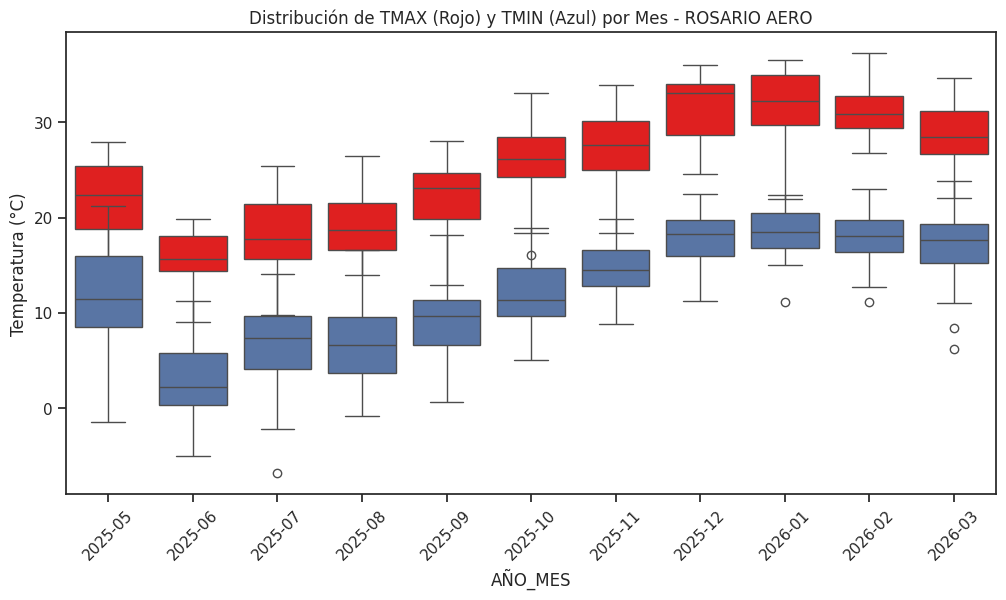

In [24]:
# Primero filtramos por fechas y lugar
fecha_inicio = '2025-05-01'
fecha_fin = '2026-04-01'
filtro_temp = temperaturas[((temperaturas['FECHA'] >= fecha_inicio) & (temperaturas['FECHA'] < fecha_fin)) & (temperaturas['NOMBRE'] == 'ROSARIO AERO')]

# Corregimos el orden de los valores, lo ponemos en ascendente
filtro_temp = filtro_temp.sort_values('FECHA', ascending=True)

# Ahora graficamos
plt.figure(figsize=(12, 6))
sns.boxplot(x='AÑO_MES', y='TMAX', data=filtro_temp, color='red')
sns.boxplot(x='AÑO_MES', y='TMIN', data=filtro_temp)
plt.title('Distribución de TMAX (Rojo) y TMIN (Azul) por Mes - ROSARIO AERO')
plt.xticks(rotation=45)
plt.ylabel('Temperatura (°C)')
plt.show()

PUNTO 4

### a. ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?
    Notamos en el gradifico que se trata del 12/2025

### b. ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?
    Se nota a 06/2025 como el mes con la menor temp mediana

### c. Considerando la variabilidad del 50 % central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas?
    El mes con menos variabilidad en ambas temperaturas es 02/2026

### d. ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?
    El mes con mayor variabilidad en sus temperaturas minimas es 05/2025

### e. Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?
    De los graficos no se notan temperaturas maximas atipicas en el invierno del 2025



# EJERCICIO 3

In [25]:
penguins = sns.load_dataset('penguins')
penguins.head(15)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [26]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


Se notan vario nulos en el df anterior. Principalmente en sex, pero al ser pocos no vale la pena eliminarlos para no perder los datos de las demas columnas

PUNTO 1

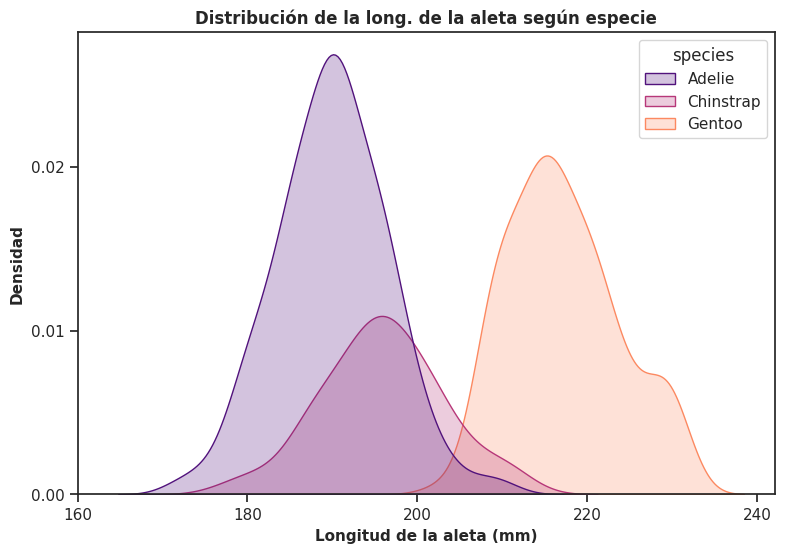

In [27]:
plt.figure(figsize=(9,6))

# Creamos el el grafico de densidad utilizando el metodo kdeplot
sns.kdeplot(data=penguins, x='flipper_length_mm', hue='species', fill=True, palette='magma')

# Definimos que las marcas del eje X vayan de 160 a 240, saltando de 20
plt.xticks(np.arange(160, 241, 20))

# Definimos que las marcas del eje y vayan de 0 a 0.02, saltando de 0.01
plt.yticks(np.arange(0, 0.03, 0.01))

# Estileamos con matplotlib
plt.xlabel('Longitud de la aleta (mm)', fontweight = 'bold', fontsize = 11)
plt.title('Distribución de la long. de la aleta según especie', fontweight = 'bold')
plt.ylabel('Densidad', fontweight = 'bold', fontsize = 11)

plt.show()

PUNTO 2

In [28]:
# Generamos la tabla usando value counts con el metodo normalize para que nos tire un valor entre 0 y 1 
tabla_porcentajes = penguins['species'].value_counts(normalize=True).round(2)*100
tabla_porcentajes

species
Adelie       44.0
Gentoo       36.0
Chinstrap    20.0
Name: proportion, dtype: float64

PUNTO 3

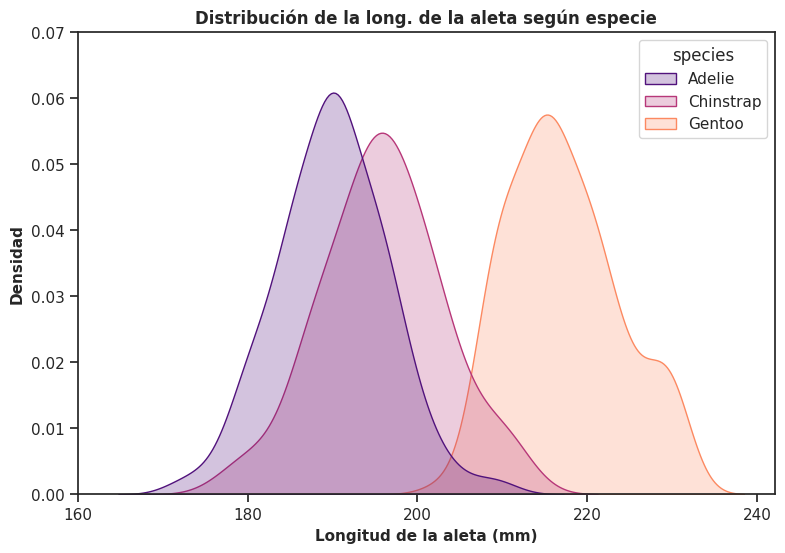

In [29]:
plt.figure(figsize=(9,6))

# Creamos el el grafico de densidad utilizando el metodo kdeplot
sns.kdeplot(data=penguins, x='flipper_length_mm', hue='species', fill=True, palette='magma', common_norm=False)

# Definimos que las marcas del eje X vayan de 160 a 240, saltando de 20
plt.xticks(np.arange(160, 241, 20))

# Definimos que las marcas del eje y vayan de 0 a 0.02, saltando de 0.01
plt.yticks(np.arange(0, 0.08, 0.01))

# Estileamos con matplotlib
plt.xlabel('Longitud de la aleta (mm)', fontweight = 'bold', fontsize = 11)
plt.title('Distribución de la long. de la aleta según especie', fontweight = 'bold')
plt.ylabel('Densidad', fontweight = 'bold', fontsize = 11)

plt.show()

Se observa, que a diferencia de la grafica anterior, esta posee una normalizacion para cada distribucion (especie). Antes la normalizacion se hacia sobre las 3, de modo que la sume de estas de 1. Ahora vemos las graficas basadas en el 100% de cada especie y no en un porcentaje de cada una (los de la tabla anterior)

PUNTO 4

In [30]:
# Calculamos el percentil 90 (el 90% de los valores acumulados hasta ahi)
penguins.groupby('species')['flipper_length_mm'].quantile(0.9)

species
Adelie       198.0
Chinstrap    205.0
Gentoo       228.0
Name: flipper_length_mm, dtype: float64

Se nota del grafico y de la tabla anterior, que la especie Adelie es la que tiene el 90% de los pinguinos con una longintud de aleta igual o menor que 198mm

## EJERCICIO 4

PUNTO 1

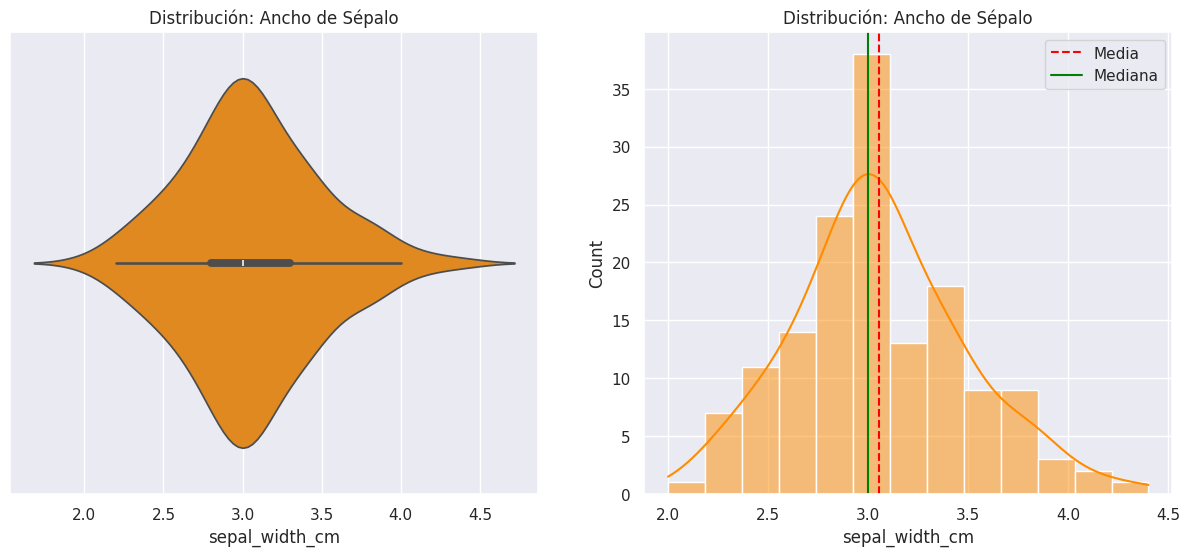

In [ ]:
# Vamos a visualizar 2 graficos a la vez para una mayor informacion

# Primero armamos el plano (subplots) para poder visualizar varios graficos. Creamos la cuadricula, 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Construimos el primer grafico, un violinplot
sns.violinplot(data=iris, x='sepal_width_cm', color='darkorange', ax=axes[0])
axes[0].set_title('Distribución: Ancho de Sépalo')

# Ahora construimos el segundo grafico, un histplot. 
# El parámetro kde=True agrega una línea suavizada sobre las barras. Es fundamental para ver la "forma" de la distribución.
sns.histplot(data=iris, x='sepal_width_cm', color='darkorange', ax=axes[1], kde=True)
axes[1].set_title('Distribución: Ancho de Sépalo')

# Vamos a agregar una línea que marque la media y la mediana en el histograma. La distancia entre ellas nos puede dar mas detalles 
# de su simetria
 
# Calculamos media y mediana
media = iris['sepal_width_cm'].mean()
mediana = iris['sepal_width_cm'].median()

# Agregamos líneas verticales al histograma (ax=axes[1])
axes[1].axvline(media, color='red', linestyle='--', label='Media')
axes[1].axvline(mediana, color='green', linestyle='-', label='Mediana')
axes[1].legend() # Para que aparezca el cuadrito con los nombres

plt.show()

De los graficos notamos que es una distribución notablemente simetrica (la media y la mediana estan bastante cerca), con forma de campana de Gauss (distribucion normal). Los mayor concentracion de los datos se encuentran en el medio.


PUNTO 2

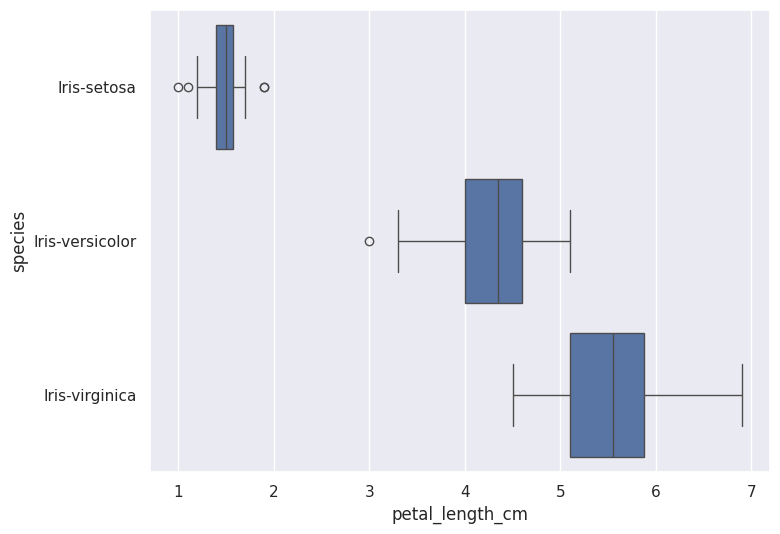

In [51]:
plt.figure(figsize=(8,6))
sns.boxplot(data=iris, y='species', x='petal_length_cm')
plt.show()

Como podemos ver, la media y la mediana tienen valores muy similares (casi identicos). Esto nos quiere decir que la distribucion de los datos es simetrica. Ademas tambien notamos las diferencias en los largos de los petalos entre las especies, siendo la iris-setosa la mas pequeña y alejada del largo de las 2 restantes, donde la diferencia es mas leve.

PUNTO 3

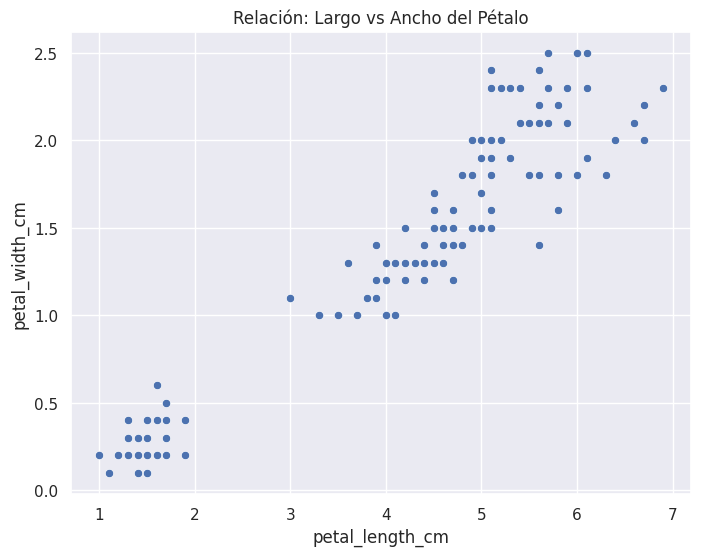

In [55]:
# Vamos a realizar un scatterplot para ver la relacion entre estas dos variables
plt.figure(figsize=(8, 6))

# Graficamos la relación general
sns.scatterplot(data=iris, x='petal_length_cm', y='petal_width_cm')
plt.title('Relación: Largo vs Ancho del Pétalo')
plt.show()

Se nota claramente en el grafico una relacion lineal directa y fuerte entre las variables largo y ancho del petalo.


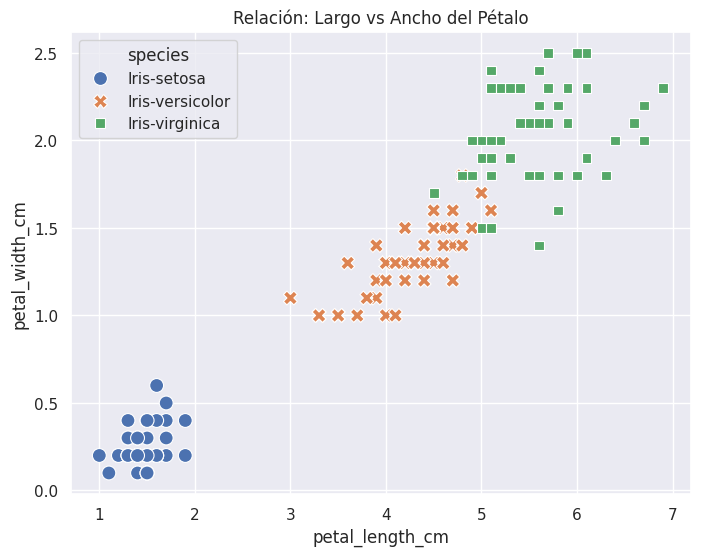

In [ ]:
plt.figure(figsize=(8, 6))

# Al grafico anterior le agregamos el parametro hue para que veamos los puntos por especie y el parametro style para que cambie la forma
# del marcador por especie. Con s (size) aumentamos el tamaño para ver mejor 
sns.scatterplot(data=iris, x='petal_length_cm', y='petal_width_cm', hue='species', style='species', s=100)
plt.title('Relación: Largo vs Ancho del Pétalo')
plt.show()

Mantenimiento de la relación: Notamos que las tres especies muestran una pendiente positiva. Es decir, el fenómeno "más largo implica más ancho" es una regla general de la naturaleza de estas flores, no algo que pase en una sola especie.

PUNTO 5

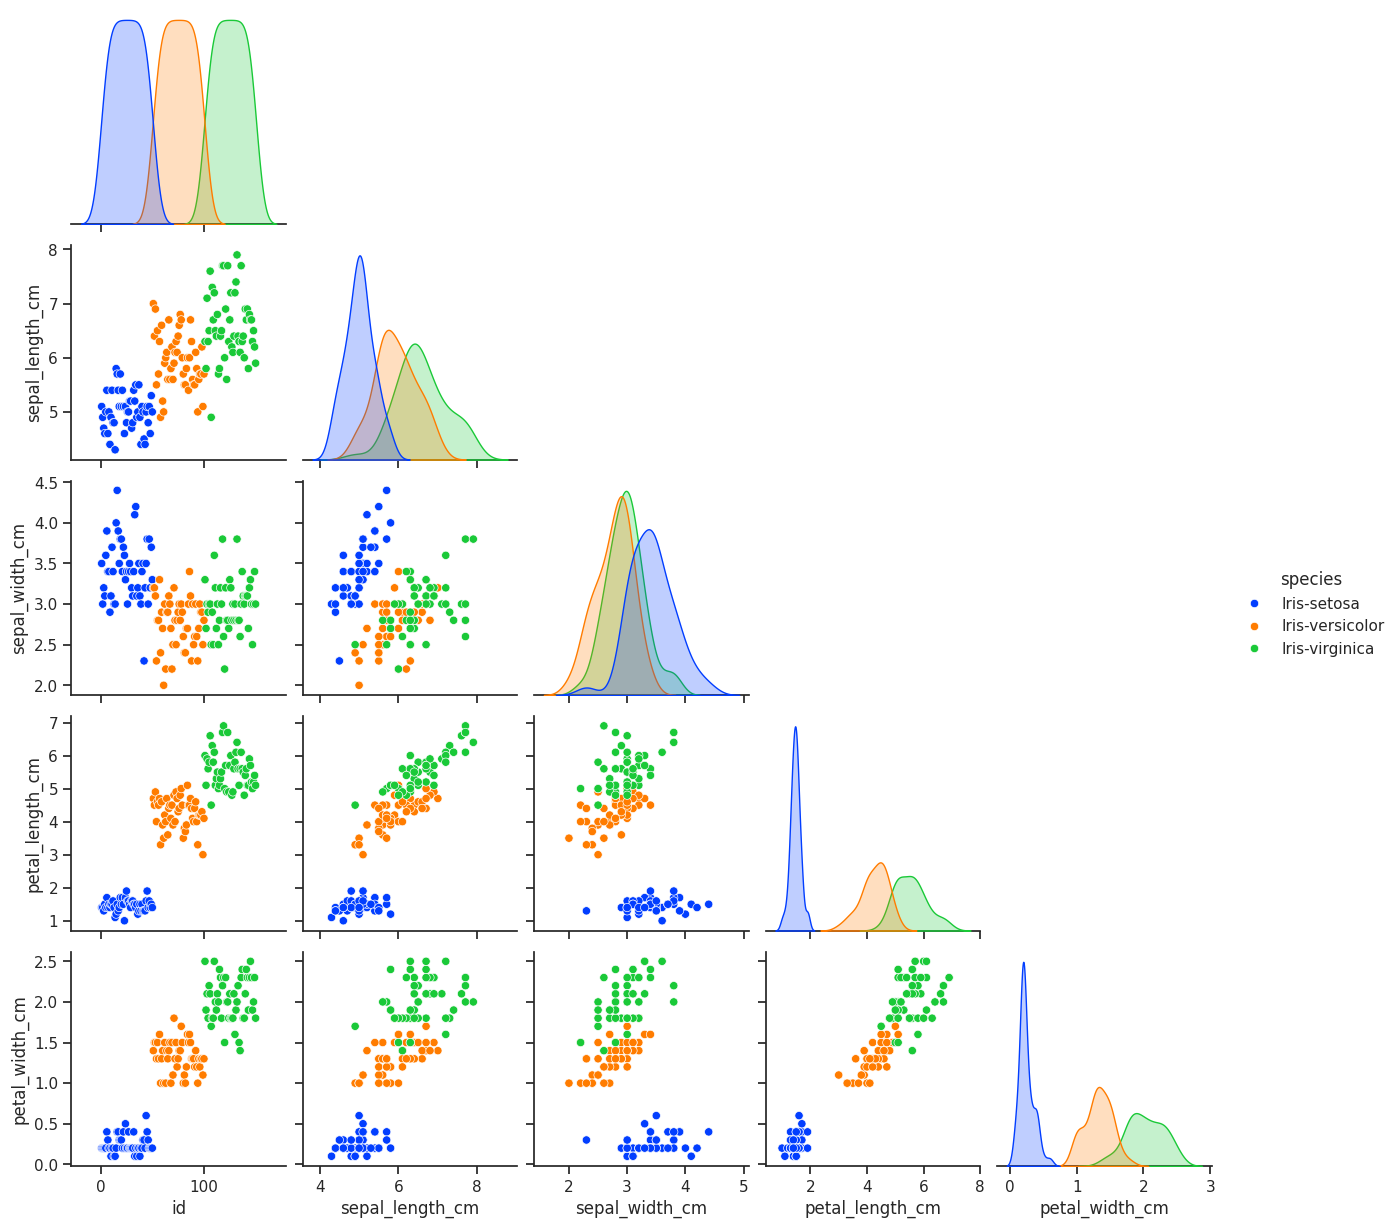

In [59]:
# Usamos pairplot para realizar un análisis exploratorio completo de todas las variables numéricas del 
# dataset, y generar una matriz de graficos

# Configuramos el estilo
sns.set_theme(style="ticks")

# Generamos la matriz de gráficos
# El parametro corner=True elimina el triángulo superior redundante (ya que es una distribucion simetrica), dejando solo la mitad inferior.
sns.pairplot(data=iris, hue='species', palette='bright', corner=True)

plt.show()

PUNTO 6

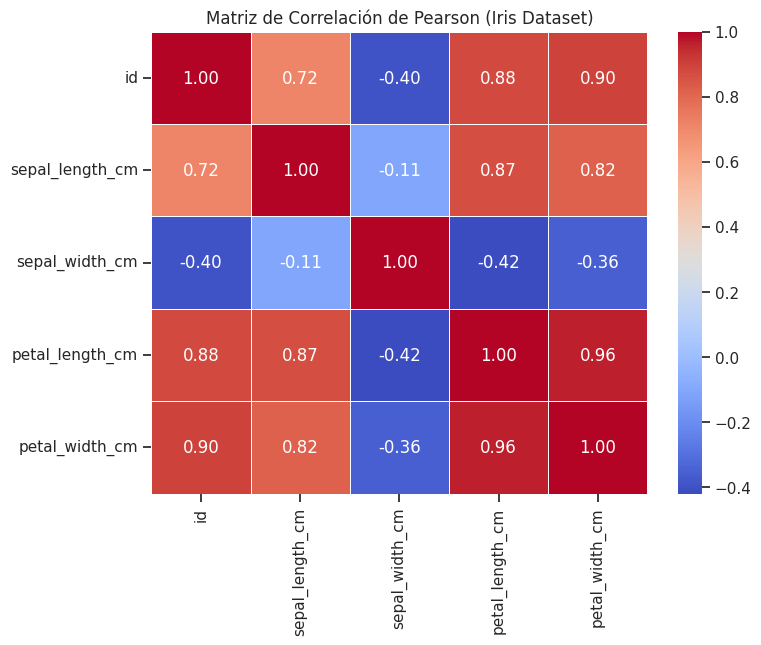

In [ ]:
# Calculamos la matriz de correlación, excluímos la columna 'species' porque no es numérica
matriz_corr = iris.drop(columns='species').corr()

# 2. Creamos el mapa de calor (Correlograma o heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, 
            annot=True,       # Muestra el número dentro de cada celda
            cmap='coolwarm',  # Escala de colores (Rojo=Positivo, Azul=Negativo)
            fmt=".2f",        # Limita a 2 decimales
            linewidths=0.5)   # Agrega una pequeña línea divisoria entre celdas

plt.title('Matriz de Correlación de Pearson (Iris Dataset)')
plt.show()

PUNTO 7

### Informe de Caracterización de Asociaciones Lineales - Dataset Iris

A partir del análisis visual realizado con el pairplot y el análisis numérico del heatmap (coeficiente de correlación de Pearson), se presentan las siguientes conclusiones sobre la relación entre las variables cuantitativas de las flores:

#### Largo del Pétalo vs. Ancho del Pétalo (r = 0.96)

Dirección: Positiva.

Fuerza: Muy fuerte.

Observación gráfica: En el pairplot se ve una línea recta ascendente muy definida. Es la relación más clara del dataset.

#### Largo del Pétalo vs. Largo del Sépalo (r = 0.87)

Dirección: Positiva.

Fuerza: Fuerte.

Observación gráfica: Los puntos forman una nube estirada hacia arriba. Hay una tendencia evidente: a mayor sépalo, mayor pétalo.

#### Ancho del Pétalo vs. Largo del Sépalo (r = 0.82)

Dirección: Positiva.

Fuerza: Fuerte.

Observación gráfica: Tendencia similar a la anterior, aunque con los puntos un poco más desparramados.

#### Ancho del Sépalo vs. Largo del Sépalo (r = -0.11)

Dirección: Negativa.

Fuerza: Muy débil (casi nula).

Observación gráfica: Los puntos forman un "manchón" o nube circular sin una dirección clara. Los números coinciden con el gráfico: no hay relación lineal.